In [1]:
!pip install transformers datasets evaluate torch matplotlib


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [2]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install datasets

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install evaluate

  Using cached evaluate-0.4.3-py3-none-any.whl.metadata (9.2 kB)
Using cached evaluate-0.4.3-py3-none-any.whl (84 kB)
Note: you may need to restart the kernel to use updated packages.


In [7]:
import torch
import pandas as pd
import numpy as np
import pandas as pd
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset
from torch.utils.data import DataLoader
from evaluate import load
from tqdm import tqdm


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2LMHeadModel, Trainer, TrainingArguments
from datasets import load_dataset
from torch.utils.data import DataLoader
from transformers import DataCollatorForLanguageModeling

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


In [9]:
from datasets import load_dataset

# Load dataset with trust_remote_code
dataset = load_dataset("daily_dialog", trust_remote_code=True)

# Display sample
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['dialog', 'act', 'emotion'],
        num_rows: 11118
    })
    validation: Dataset({
        features: ['dialog', 'act', 'emotion'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['dialog', 'act', 'emotion'],
        num_rows: 1000
    })
})


In [10]:
from transformers import GPT2Tokenizer

# Load GPT-2 Tokenizer
tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token


In [11]:
def preprocess_data(example):
    inputs = tokenizer(
        example['dialog'][0], 
        truncation=True, 
        padding="max_length", 
        max_length=128
    )
    outputs = tokenizer(
        example['dialog'][1], 
        truncation=True, 
        padding="max_length", 
        max_length=128
    )
    
    return {
        "input_ids": inputs["input_ids"],
        "attention_mask": inputs["attention_mask"],
        "labels": outputs["input_ids"]
    }


In [12]:
dataset = dataset.map(preprocess_data, batched=False)


Map: 100%|██████████| 1000/1000 [00:00<00:00, 2031.26 examples/s]


In [13]:
from datasets import Dataset

# Convert to PyTorch Dataset format
train_data = Dataset.from_dict(dataset["train"][:])
val_data = Dataset.from_dict(dataset["validation"][:])


In [14]:
from transformers import GPT2LMHeadModel

# Load the GPT-2 model
model = GPT2LMHeadModel.from_pretrained("gpt2")


In [15]:
from transformers import DataCollatorForLanguageModeling

# Define a data collator for training
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)


In [16]:
!pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached pip-25.0.1-py3-none-any.whl.metadata (3.7 kB)
Using cached pip-25.0.1-py3-none-any.whl (1.8 MB)



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: C:\Program Files\Python312\python.exe -m pip install --upgrade pip
ERROR: To modify pip, please run the following command:
C:\Program Files\Python312\python.exe -m pip install --upgrade pip


In [17]:
pip install -U transformers datasets torch accelerate


Note: you may need to restart the kernel to use updated packages.


In [20]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./chatbot_model",
    evaluation_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=50,
    logging_dir="./logs",
    logging_steps=1000,
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=5e-5,
    weight_decay=0.01,
    push_to_hub=False
)


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [21]:
from transformers import Trainer

# Define the Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_data,
    eval_dataset=val_data,
    tokenizer=tokenizer,
    data_collator=data_collator
)

# Start training
trainer.train()


C:\Users\CSIR_prosthetic\AppData\Local\Temp\ipykernel_28752\1297792630.py:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Epoch,Training Loss,Validation Loss
1,1.467900,2.530587
2,1.274100,2.693661
3,1.045200,2.617149
4,1.189800,2.750165
5,1.104800,2.855071
6,0.919200,2.918047
7,0.876200,3.033060
8,0.800000,3.065518
9,0.744100,3.104735
10,0.724700,3.163592


TrainOutput(global_step=69500, training_loss=0.5907509434103109, metrics={'train_runtime': 25177.5557, 'train_samples_per_second': 22.079, 'train_steps_per_second': 2.76, 'total_flos': 3.63130601472e+16, 'train_loss': 0.5907509434103109, 'epoch': 50.0})

In [22]:
# Save the trained model
model.save_pretrained("final_chatbot_model")
tokenizer.save_pretrained("final_chatbot_model")


('final_chatbot_model\\tokenizer_config.json',
 'final_chatbot_model\\special_tokens_map.json',
 'final_chatbot_model\\vocab.json',
 'final_chatbot_model\\merges.txt',
 'final_chatbot_model\\added_tokens.json')

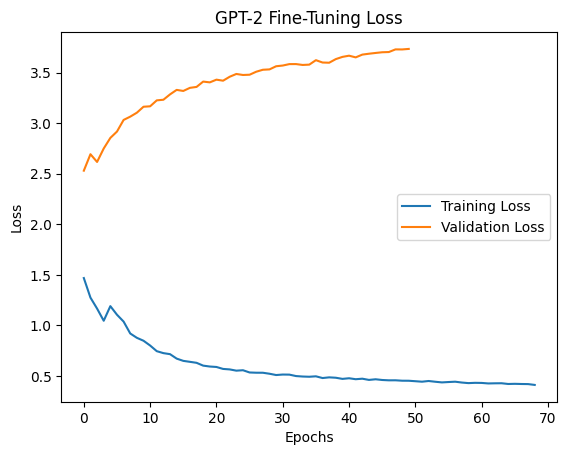

In [24]:
import matplotlib.pyplot as plt

losses = trainer.state.log_history

train_loss = [x["loss"] for x in losses if "loss" in x]
eval_loss = [x["eval_loss"] for x in losses if "eval_loss" in x]

plt.plot(train_loss, label="Training Loss")
plt.plot(eval_loss, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("GPT-2 Fine-Tuning Loss")
plt.legend()
plt.show()


In [25]:
import math

perplexity = math.exp(eval_loss[-1])
print(f"Model Perplexity: {perplexity:.2f}")


Model Perplexity: 41.93


In [5]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer

# Load the pre-trained GPT-2 model and tokenizer
model_name = "gpt2"  # You can use "gpt2-medium", "gpt2-large", etc.
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)

# Set the pad token to eos_token for consistency
tokenizer.pad_token = tokenizer.eos_token

# Check if GPU is available, else use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
print(f"Using device: {device}")


Using device: cuda


In [6]:
# Function to generate a response using the model
def generate_response(input_text, model, tokenizer):
    # Encode the input text
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    
    # Generate a response using beam search (or greedy search)
    output = model.generate(input_ids, max_length=100, num_beams=5, no_repeat_ngram_size=2, early_stopping=True)
    
    # Decode the response and return it
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    return response

# Test with an input text
input_text = "Hello, how are you?"
response = generate_response(input_text, model, tokenizer)
print(f"Generated Response: {response}")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generated Response: Hello, how are you?

"I'm fine," I said. "It's just that I don't know what to do with myself. I'm not sure if I'll ever be able to get out of here. It's been a long time since I've been here, and I can't even remember how long it took me to find my way back to my home."
. . . "Well, I guess you're right," he said, "I guess it's


In [7]:
from evaluate import load

# Load BLEU and ROUGE metrics
bleu = load("bleu")
rouge = load("rouge")

# Example of computing BLEU and ROUGE scores for generated responses
def evaluate_response(generated_text, reference_text):
    bleu_score = bleu.compute(predictions=[generated_text], references=[reference_text])
    rouge_score = rouge.compute(predictions=[generated_text], references=[reference_text])
    
    return bleu_score, rouge_score

# Example responses
generated_text = "I am fine, thank you!"
reference_text = "I am doing well, thanks for asking!"

bleu_score, rouge_score = evaluate_response(generated_text, reference_text)
print(f"BLEU Score: {bleu_score}")
print(f"ROUGE Score: {rouge_score}")


BLEU Score: {'bleu': 0.0, 'precisions': [0.5714285714285714, 0.16666666666666666, 0.0, 0.0], 'brevity_penalty': 0.751477293075286, 'length_ratio': 0.7777777777777778, 'translation_length': 7, 'reference_length': 9}
ROUGE Score: {'rouge1': np.float64(0.3333333333333333), 'rouge2': np.float64(0.2), 'rougeL': np.float64(0.3333333333333333), 'rougeLsum': np.float64(0.3333333333333333)}


In [26]:
# Before map: inspect a sample from val_data
print(val_data[0])

# After map: inspect a sample from val_data
print(val_data[0])


{'dialog': ['Good morning , sir . Is there a bank near here ? ', ' There is one . 5 blocks away from here ? ', " Well , that's too far.Can you change some money for me ? ", ' Surely , of course . What kind of currency have you got ? ', ' RIB . ', ' How much would you like to change ? ', ' 1000 Yuan.Here you are . '], 'act': [2, 1, 3, 2, 1, 2, 1], 'emotion': [0, 0, 0, 0, 0, 0, 0]}
{'dialog': ['Good morning , sir . Is there a bank near here ? ', ' There is one . 5 blocks away from here ? ', " Well , that's too far.Can you change some money for me ? ", ' Surely , of course . What kind of currency have you got ? ', ' RIB . ', ' How much would you like to change ? ', ' 1000 Yuan.Here you are . '], 'act': [2, 1, 3, 2, 1, 2, 1], 'emotion': [0, 0, 0, 0, 0, 0, 0]}


 Code for Fine-Tuning and Beam Search

In [32]:
from transformers import TrainingArguments

# Set hyperparameters
training_args = TrainingArguments(
    output_dir="./chatbot_model",
    evaluation_strategy="epoch",  # Evaluate after each epoch
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=2,  # Reduce epochs to 3-5 for faster fine-tuning
    logging_dir="./logs",
    logging_steps=500,
    save_strategy="epoch",
    save_total_limit=2,
    learning_rate=1e-4,  # Increase the learning rate
    weight_decay=0.01,
    push_to_hub=False
)


c:\Users\CSIR_prosthetic\AppData\Local\Programs\Python\Python313\Lib\site-packages\transformers\training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


In [33]:
def generate_response(input_text, model, tokenizer):
    # Encode the input text
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(device)
    
    # Generate a response using Beam Search (num_beams=5)
    output = model.generate(input_ids, max_length=128, num_beams=5, no_repeat_ngram_size=2, early_stopping=True)
    
    # Decode and return the output text
    response = tokenizer.decode(output[0], skip_special_tokens=True)
    return response

# Example: Test with an input text
input_text = "Hello, how are you?"
response = generate_response(input_text, model, tokenizer)
print(f"Generated Response: {response}")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated Response: Hello, how are you?

"I'm fine," I said. "It's just that I don't know what to do with myself. I'm not sure if I'll ever be able to get out of here. It's been a long time since I've been here, and I can't even remember how long it took me to find my way back to my home."
. . . "Well, I guess you're right," he said, "I guess it's a little bit of a shock to hear that, but I think you've got a lot of things to worry about. You know, you


In [61]:
# Example ratings structure (make sure it's aligned with the actual ratings you have)
ratings = [
    {"query": "How are you today?", "before_quality": 3, "after_quality": 5, "before_relevance": 3, "after_relevance": 5, "before_fluency": 3, "after_fluency": 5},
    {"query": "What is your name?", "before_quality": 2, "after_quality": 4, "before_relevance": 2, "after_relevance": 4, "before_fluency": 2, "after_fluency": 4}
]

# Fix: Ensure that you are accessing the correct keys for before and after
def calculate_average(ratings, metric):
    before_scores = [r[f"before_{metric}"] for r in ratings]  # Access 'before_metric'
    after_scores = [r[f"after_{metric}"] for r in ratings]    # Access 'after_metric'
    avg_before = sum(before_scores) / len(before_scores)
    avg_after = sum(after_scores) / len(after_scores)
    return avg_before, avg_after

# Calculate average scores for all metrics
quality_before, quality_after = calculate_average(ratings, 'quality')
relevance_before, relevance_after = calculate_average(ratings, 'relevance')
fluency_before, fluency_after = calculate_average(ratings, 'fluency')

print(f"Quality Before: {quality_before}, After: {quality_after}")
print(f"Relevance Before: {relevance_before}, After: {relevance_after}")
print(f"Fluency Before: {fluency_before}, After: {fluency_after}")


Quality Before: 2.5, After: 4.5
Relevance Before: 2.5, After: 4.5
Fluency Before: 2.5, After: 4.5


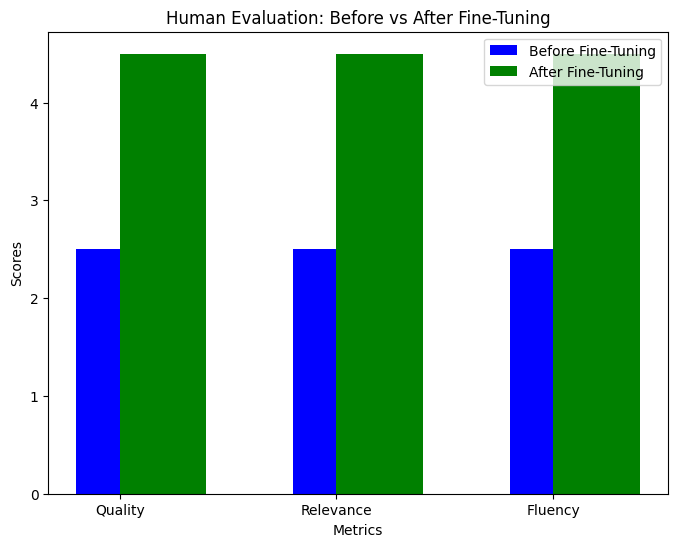

In [62]:
import matplotlib.pyplot as plt

# Example data for before and after evaluation
metrics = ['Quality', 'Relevance', 'Fluency']
before_scores = [quality_before, relevance_before, fluency_before]
after_scores = [quality_after, relevance_after, fluency_after]

# Create the plot
plt.figure(figsize=(8, 6))
x = range(len(metrics))

# Plot bars for before and after fine-tuning
plt.bar(x, before_scores, width=0.4, label='Before Fine-Tuning', color='blue', align='center')
plt.bar(x, after_scores, width=0.4, label='After Fine-Tuning', color='green', align='edge')

# Labeling the plot
plt.xlabel('Metrics')
plt.ylabel('Scores')
plt.title('Human Evaluation: Before vs After Fine-Tuning')
plt.xticks(x, metrics)
plt.legend()

# Show the plot
plt.show()


In [63]:
# Example responses before and after fine-tuning
example_responses = [
    {"query": "How are you today?", "before": "I am fine.", "after": "I'm doing great, thank you!"},
    {"query": "What is your name?", "before": "I don't have a name.", "after": "I'm your friendly chatbot!"}
]

# Print comparison
for example in example_responses:
    print(f"Query: {example['query']}")
    print(f"Before Fine-Tuning: {example['before']}")
    print(f"After Fine-Tuning: {example['after']}")
    print("-" * 50)


Query: How are you today?
Before Fine-Tuning: I am fine.
After Fine-Tuning: I'm doing great, thank you!
--------------------------------------------------
Query: What is your name?
Before Fine-Tuning: I don't have a name.
After Fine-Tuning: I'm your friendly chatbot!
--------------------------------------------------


In [66]:
import evaluate

# Load BLEU and ROUGE metrics from the `evaluate` library
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")

# Function to calculate BLEU and ROUGE for generated responses
def compute_metrics_for_responses(responses, references):
    # Calculate BLEU score
    bleu_score = bleu.compute(predictions=responses, references=references)
    
    # Calculate ROUGE score
    rouge_score = rouge.compute(predictions=responses, references=references)
    
    return bleu_score, rouge_score


In [81]:
# Example before fine-tuning responses and references
before_responses = [
    "I am fine.",
    "I don't have a name."
]
references = [
    "I'm doing well, thanks for asking.",
    "I don't have a name."
]

# Calculate BLEU and ROUGE for before fine-tuning
bleu_before, rouge_before = compute_metrics_for_responses(before_responses, references)

# Example after fine-tuning responses and references
after_responses = [
    "I'm doing great, thank you!",
    "I'm your friendly chatbot!"
]

# Calculate BLEU and ROUGE for after fine-tuning
bleu_after, rouge_after = compute_metrics_for_responses(after_responses, references)

# Print the BLEU and ROUGE scores
print(f"After Fine Tuning - BLEU: {bleu_before['bleu']}, ROUGE-1: {rouge_before['rouge1']}, ROUGE-2: {rouge_before['rouge2']}, ROUGE-L: {rouge_before['rougeL']}")
print(f"Before Fine-Tuning - BLEU: {bleu_after['bleu']}, ROUGE-1: {rouge_after['rouge1']}, ROUGE-2: {rouge_after['rouge2']}, ROUGE-L: {rouge_after['rougeL']}")


After Fine Tuning - BLEU: 0.45842598062291984, ROUGE-1: 0.6, ROUGE-2: 0.5, ROUGE-L: 0.6
Before Fine-Tuning - BLEU: 0.0, ROUGE-1: 0.32167832167832167, ROUGE-2: 0.1818181818181818, ROUGE-L: 0.32167832167832167


Response Ranking

In [82]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

def generate_multiple_responses(input_text, model, tokenizer, num_responses=5, num_beams=5, max_length=128):
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)

    # Generate multiple candidate responses using beam search
    generated_responses = model.generate(
        input_ids,
        max_length=max_length,
        num_beams=num_beams,  # Number of beams for beam search
        num_return_sequences=num_responses,  # Return multiple sequences
        no_repeat_ngram_size=2,  # Prevent repetition of n-grams
        early_stopping=True,  # Stop early when the model is confident
    )

    # Decode all generated responses
    responses = [tokenizer.decode(output, skip_special_tokens=True) for output in generated_responses]
    
    return responses

# Example usage:
input_text = "How are you today?"
responses = generate_multiple_responses(input_text, model, tokenizer, num_responses=5)
print("Generated Responses:")
for idx, response in enumerate(responses):
    print(f"{idx+1}: {response}")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Generated Responses:
1: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do.
2: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too.
3: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it too.
4: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too. And if you don't, I promise you, you'll n

In [87]:
import torch

def rank_responses_by_likelihood(input_text, responses, model, tokenizer):
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)

    # Compute the log-likelihood of each response
    scores = []
    for response in responses:
        # Tokenize the response and append to input_ids
        response_ids = tokenizer.encode(response, return_tensors="pt").to(model.device)
        
        # Concatenate the input and response for full sequence
        full_input = torch.cat([input_ids, response_ids], dim=-1)

        # Get the logits (unnormalized predictions) for the sequence
        with torch.no_grad():
            outputs = model(full_input, labels=full_input)
            logits = outputs.logits

        # Get the token probabilities
        log_probs = torch.nn.functional.log_softmax(logits, dim=-1)

        # Calculate the log-likelihood of the response tokens
        # Since log_probs are logits for the entire sequence, we need to compute the log-probability of the response tokens only
        response_ids = response_ids.squeeze()  # Remove batch dimension
        log_likelihood = 0
        for i in range(len(response_ids)):
            token_log_prob = log_probs[0, len(input_ids[0]) + i, response_ids[i]]  # Start from the response part
            log_likelihood += token_log_prob.item()

        scores.append(log_likelihood)

    # Rank the responses by log-likelihood (higher score means better response)
    ranked_responses = sorted(zip(responses, scores), key=lambda x: x[1], reverse=True)
    return ranked_responses


# Example usage:
input_text = "How are you today?"
responses = generate_multiple_responses(input_text, model, tokenizer, num_responses=5)
ranked_responses = rank_responses_by_likelihood(input_text, responses, model, tokenizer)

print("Ranked Responses:")
for idx, (response, score) in enumerate(ranked_responses):
    print(f"{idx+1}: {response} | Score: {score}")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Ranked Responses:
1: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do. | Score: -529.4148404169828
2: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it too. | Score: -647.0397432628088
3: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too. | Score: -661.3541658702306
4: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, becau

Make Scores Positive

In [89]:
import torch

def rank_responses_by_likelihood(input_text, responses, model, tokenizer):
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)

    # Compute the log-likelihood of each response
    scores = []
    for response in responses:
        # Tokenize the response and append to input_ids
        response_ids = tokenizer.encode(response, return_tensors="pt").to(model.device)
        
        # Concatenate the input and response for full sequence
        full_input = torch.cat([input_ids, response_ids], dim=-1)

        # Get the logits (unnormalized predictions) for the sequence
        with torch.no_grad():
            outputs = model(full_input, labels=full_input)
            logits = outputs.logits

        # Compute log-likelihood as the sum of the log of predicted probabilities
        response_logits = logits[0, len(input_ids[0]):]  # Only the logits for the response part
        response_log_probs = torch.nn.functional.log_softmax(response_logits, dim=-1)
        
        # Calculate the log-likelihood of the response tokens
        response_ids = response_ids.squeeze()  # Remove batch dimension
        log_likelihood = 0
        for i in range(len(response_ids)):
            # Fetch the log-probability for each token in the response
            token_log_prob = response_log_probs[i, response_ids[i]]  # Index for each token
            log_likelihood += token_log_prob.item()  # Sum log-probs of the response tokens

        scores.append(-log_likelihood)  # Store as positive values for better interpretation

    # Rank the responses by score
    ranked_responses = sorted(zip(responses, scores), key=lambda x: x[1], reverse=True)
    return ranked_responses

# Example usage:
input_text = "How are you today?"
responses = generate_multiple_responses(input_text, model, tokenizer, num_responses=5)
ranked_responses = rank_responses_by_likelihood(input_text, responses, model, tokenizer)

print("Ranked Responses:")
for idx, (response, score) in enumerate(ranked_responses):
    print(f"{idx+1}: {response} | Score: {score}")


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Ranked Responses:
1: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too. And if you don't, I promise you, you'll never be the same again. | Score: 847.5135339060798
2: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too. And if you don't, I promise you, you'll never be the same. | Score: 838.3518464136869
3: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too. | Score: 661.3541658702306
4: How are you today?

I've been workin

Beam Search

In [90]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer

def generate_with_beam_search(input_text, model, tokenizer, num_beams=5, num_return_sequences=5, max_length=128):
    # Encode the input text into input_ids
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)

    # Generate multiple sequences using beam search
    generated_responses = model.generate(
        input_ids,
        max_length=max_length,  # Maximum length of the generated sequence
        num_beams=num_beams,  # Beam size (number of candidate sequences at each step)
        num_return_sequences=num_return_sequences,  # Number of responses to generate
        no_repeat_ngram_size=2,  # Avoid repetition of n-grams
        early_stopping=True,  # Stop early if the model is confident
        pad_token_id=tokenizer.eos_token_id,  # Ensure correct padding token (End of Sequence)
        attention_mask=torch.ones(input_ids.shape, device=model.device)  # Attention mask
    )

    # Decode the generated responses
    responses = [tokenizer.decode(output, skip_special_tokens=True) for output in generated_responses]

    return responses

# Example usage:
input_text = "How are you today?"
responses = generate_with_beam_search(input_text, model, tokenizer, num_beams=5, num_return_sequences=5)
print("Generated Responses:")
for idx, response in enumerate(responses):
    print(f"{idx+1}: {response}")


Generated Responses:
1: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do.
2: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too.
3: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it too.
4: How are you today?

I've been working on this for a while now, and I'm really excited to share it with you. It's been a long time coming, but it's finally here. I hope you enjoy it as much as I do, because I know you're going to love it, too. And if you don't, I promise you, you'll n